<a href="https://colab.research.google.com/github/imjesusgarcia/Project-ConnectaTel-Student/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:
- El dataset no tiene valores ausentes.
- La columna date es de tipo object y debería ser datetime. Se convertirá cuando el análisis lo requiera.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
# Verificar usuarios únicos
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df[['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']].apply(pd.Series.value_counts))


Conteo de categorías:
            landing   region  dispositivo  traffic_source  user_type
A           19982.0      NaN          NaN             NaN        NaN
Ads             NaN      NaN          NaN         11935.0        NaN
B           20018.0      NaN          NaN             NaN        NaN
Centro          NaN   9613.0          NaN             NaN        NaN
Desktop         NaN      NaN      15171.0             NaN        NaN
Email           NaN      NaN          NaN          6123.0        NaN
Mobile          NaN      NaN      24829.0             NaN        NaN
Norte           NaN  11166.0          NaN             NaN        NaN
Nuevo           NaN      NaN          NaN             NaN    26033.0
Occidente       NaN   6398.0          NaN             NaN        NaN
Organic         NaN      NaN          NaN         17987.0        NaN
Oriente         NaN   4784.0          NaN             NaN        NaN
Recurrente      NaN      NaN          NaN             NaN    13967.0
Referral   

In [ ]:
df['landing'].value_counts()

B    20018
A    19982
Name: landing, dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

- Todas las columnas tienen valores esperados.
- El experimento está balanceado: versión B con 20,018 usuarios y versión A con 19,982.
- El experimento abarca 28 días (2026-01-01 al 2026-01-28).
- Los 40,000 usuarios son únicos, sin duplicados.
- El gasto promedio general es bajo (9.33) porque incluye no convertidos. Filtrando solo convertidos (5,706 usuarios), el gasto promedio sube a 65.37 con un máximo de 303.68.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
print("Gasto promedio A:", gasto_A.mean())
print("Gasto promedio B:", gasto_B.mean())

Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de usuarios convertidos es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de usuarios convertidos es diferente entre la página A y la página B.

In [ ]:
# Aplicar prueba
t_stat, p_value = stats.ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico t: -9.3656
Valor p: 0.0000


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Se rechaza H₀: hay diferencia significativa en el gasto promedio.")
else:
    print("No se rechaza H₀: no hay diferencia significativa en el gasto promedio.")

Se rechaza H₀: hay diferencia significativa en el gasto promedio.


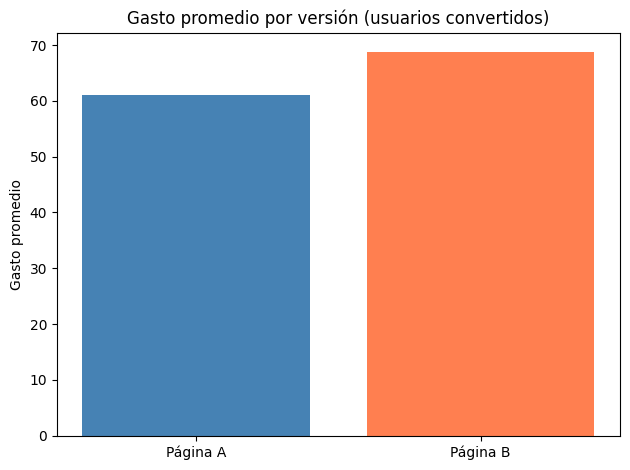

In [ ]:
# Visualización
fig, ax = plt.subplots()
ax.bar(["Página A", "Página B"], [gasto_A.mean(), gasto_B.mean()], color=["steelblue", "coral"])
ax.set_title("Gasto promedio por versión (usuarios convertidos)")
ax.set_ylabel("Gasto promedio")
plt.tight_layout()
plt.show()

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza H₀ (p = 0.0000 < 0.05).

**Interpretación de negocio:**  
Existe una diferencia estadísticamente significativa en el gasto promedio entre ambas versiones. Los usuarios convertidos en la página B gastaron en promedio $68.75 Frente a $61.09 en la página A. Esto representa aproximadamente $7.66 más por cliente en la versión B, lo que se asocia con un mayor valor económico por usuario convertido.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [ ]:
# Número de usuarios convertidos por página
convertidos = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(convertidos.values, totales.values)

# Visualizar resultados
print(f"Estadístico z: {z_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico z: -9.6774
Valor p: 0.0000


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza H₀ (p = 0.0000 < 0.05).

**Interpretación de negocio:**  
Existe una diferencia estadísticamente significativa en la tasa de conversión entre ambas versiones. La página B convirtió 3,194 de 20,018 usuarios (15.96%), mientras que la página A convirtió 2,512 de 19,982 (12.57%). La página B se asocia con una tasa de conversión aproximadamente 3.4 puntos porcentuales mayor, lo que representa un incremento relevante para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico y la conversión son independientes (no existe asociación entre ellas).
- **Hipótesis alternativa (H₁):** Existe una asociación entre la fuente de tráfico y la conversión.

In [ ]:
# Tabla de contingencia
contingency_table = pd.crosstab(df["traffic_source"], df["converted"])
print(contingency_table)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Estadístico chi2: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Grados de libertad: {dof}")

Estadístico chi2: 8.6621
Valor p: 0.0341
Grados de libertad: 3


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Se rechaza H₀: existe asociación entre fuente de tráfico y conversión.")
else:
    print("No se rechaza H₀: no existe asociación entre fuente de tráfico y conversión.")

Se rechaza H₀: existe asociación entre fuente de tráfico y conversión.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza H₀ (p = 0.0341 < 0.05).

**Interpretación de negocio:**  
fuente de tráfico y la conversión. Calculando las tasas por canal: Email (15.0%), Ads (14.7%), Organic (13.8%) y Referral (13.9%). Email y Ads muestran las tasas más altas, lo que sugiere que los usuarios que llegan por estos canales tienen mayor propensión a convertir. Esto permite orientar la inversión en marketing hacia los canales más efectivos.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario y la conversión son independientes (no existe asociación entre ellos).
- **Hipótesis alternativa (H₁):** Existe una asociación entre el tipo de usuario y la conversión.

In [ ]:
# Tabla de contingencia
contingency_table2 = pd.crosstab(df["user_type"], df["converted"])
print(contingency_table2)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
# Tasa de conversión por tipo de usuario
print(df.groupby("user_type")["converted"].mean())

user_type
Nuevo         0.143587
Recurrente    0.140904
Name: converted, dtype: float64


In [ ]:
# Aplicar prueba
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table2)
print(f"Estadístico chi2: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Grados de libertad: {dof}")

Estadístico chi2: 0.5135
Valor p: 0.4736
Grados de libertad: 1


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza H₀ (p = 0.4736 > 0.05).

**Interpretación de negocio:**  
No existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión. Las tasas son prácticamente idénticas: usuarios nuevos (14.36%) y recurrentes (14.09%). El tipo de usuario no se asocia con mayor o menor probabilidad de convertir, por lo que segmentar la estrategia de marketing por este criterio no estaría respaldado por los datos.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

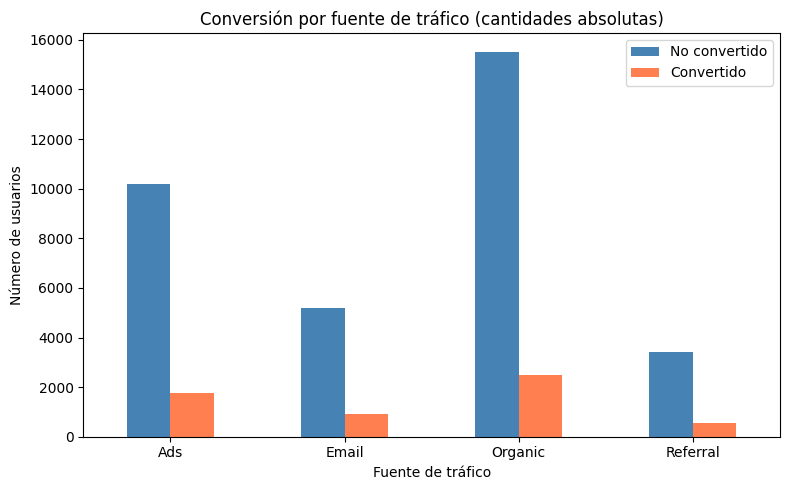

In [ ]:
# Gráfico de barras agrupadas - cantidades absolutas
traffic_conv = pd.crosstab(df["traffic_source"], df["converted"])
traffic_conv.columns = ["No convertido", "Convertido"]
traffic_conv.plot(kind="bar", figsize=(8, 5), color=["steelblue", "coral"])
plt.title("Conversión por fuente de tráfico (cantidades absolutas)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

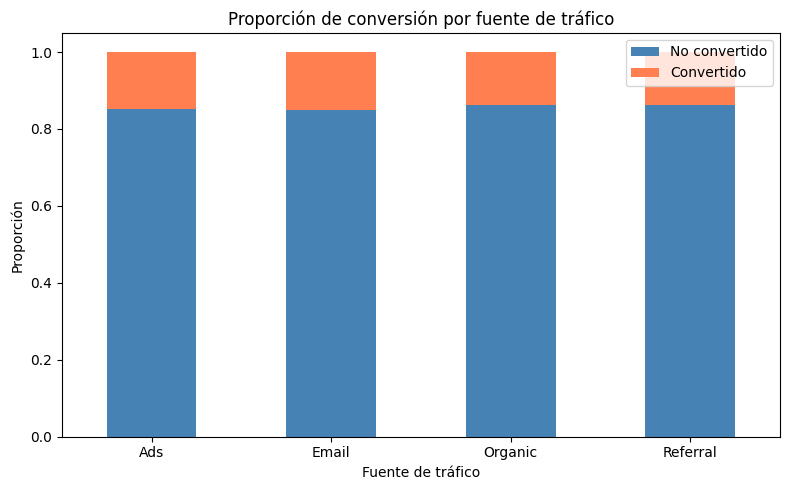

In [ ]:
# Gráfico de barras apiladas - proporciones
traffic_prop = traffic_conv.div(traffic_conv.sum(axis=1), axis=0)
traffic_prop.plot(kind="bar", stacked=True, figsize=(8, 5), color=["steelblue", "coral"])
plt.title("Proporción de conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

✍️ **Comentario**:

**Gráfico 1** (barras agrupadas): Muestra el volumen absoluto por canal.
**Organic** tiene el mayor número de usuarios totales, pero también el mayor volumen de no convertidos. **Email** tiene menos usuarios pero proporcionalmente más conversiones.

**Gráfico 2** (barras apiladas): Muestra la proporción de conversión por canal. Las diferencias son pequeñas pero visibles
**Email** y **Ads** tienen una franja naranja ligeramente mayor, confirmando su mayor tasa de conversión relativa

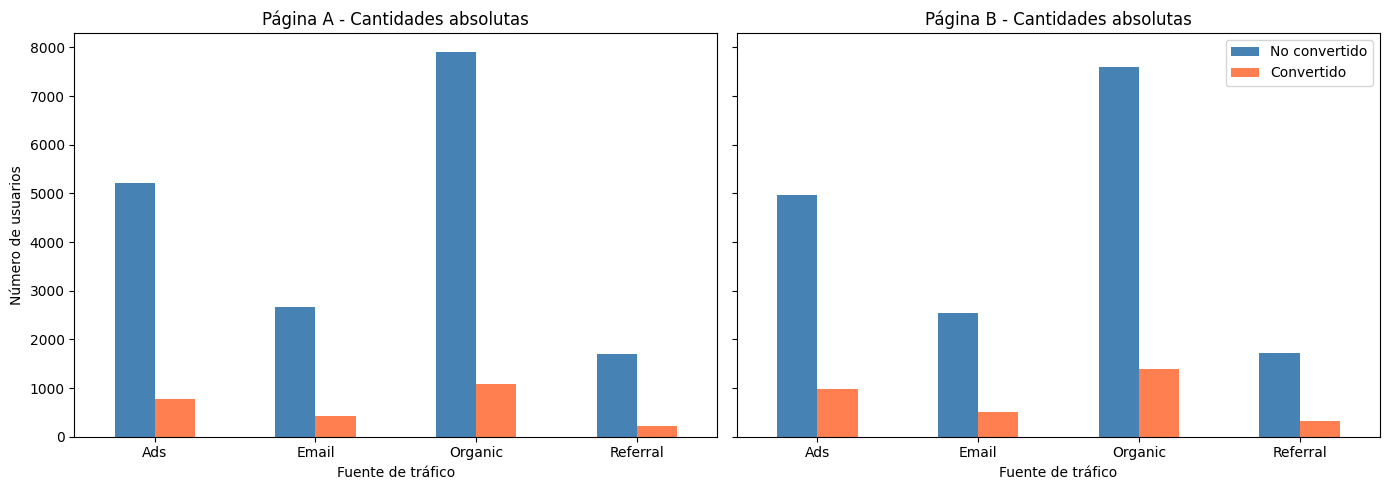

In [ ]:
# Gráfico de barras agrupadas por página - cantidades absolutas
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pagina in zip(axes, ["A", "B"]):
    subset = df[df["landing"] == pagina]
    traffic_conv = pd.crosstab(subset["traffic_source"], subset["converted"])
    traffic_conv.columns = ["No convertido", "Convertido"]
    traffic_conv.plot(kind="bar", ax=ax, color=["steelblue", "coral"], legend=(ax == axes[1]))
    ax.set_title(f"Página {pagina} - Cantidades absolutas")
    ax.set_xlabel("Fuente de tráfico")
    ax.set_ylabel("Número de usuarios")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

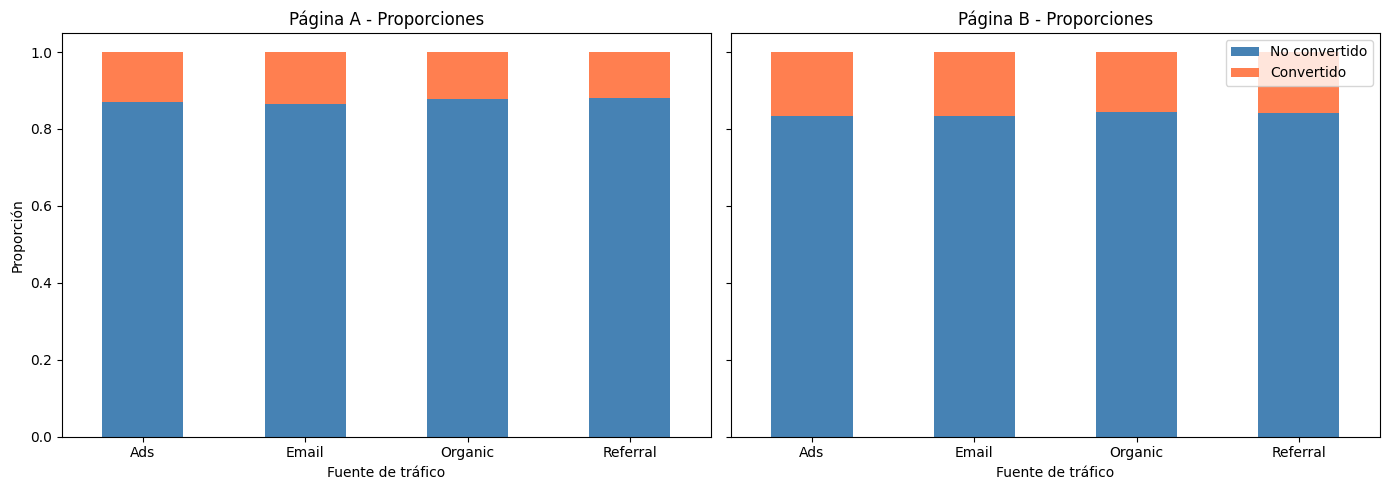

In [ ]:
# Gráfico de barras apiladas por página - proporciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pagina in zip(axes, ["A", "B"]):
    subset = df[df["landing"] == pagina]
    traffic_conv = pd.crosstab(subset["traffic_source"], subset["converted"])
    traffic_conv.columns = ["No convertido", "Convertido"]
    traffic_prop = traffic_conv.div(traffic_conv.sum(axis=1), axis=0)
    traffic_prop.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "coral"], legend=(ax == axes[1]))
    ax.set_title(f"Página {pagina} - Proporciones")
    ax.set_xlabel("Fuente de tráfico")
    ax.set_ylabel("Proporción")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
print(df.groupby(["landing", "traffic_source"])["converted"].mean().round(4) * 100)

landing  traffic_source
A        Ads               12.99
         Email             13.51
         Organic           12.11
         Referral          11.91
B        Ads               16.49
         Email             16.50
         Organic           15.46
         Referral          15.74
Name: converted, dtype: float64


✍️ **Comentario**:

Gráfico 1:
La distribución de volumen por canal es prácticamente idéntica entre ambas páginas. Organic atrae más usuarios en ambos casos, seguido de Ads, Email y Referral.
Gráfico 2 (proporciones):

Lo más relevante es que la página B supera a la página A en todos los canales sin excepción.

- **Ads**, B convierte al 16.49% vs 12.99% de A.
- **Email**, 16.50% vs 13.51%.
- **Organic**, 15.46% vs 12.11%.
- **Referral**, 15.74% vs 11.91%.

La ventaja de B es consistente en aproximadamente 3 a 4 puntos porcentuales en cada canal.
Esto es un hallazgo importante: la superioridad de la página B no está concentrada en un canal específico, sino que se repite de forma uniforme en todos los canales de tráfico, lo que refuerza que la diferencia se debe al diseño de la página y no al tipo de audiencia que llega.

### Relación entre el tipo de usuario y la conversión

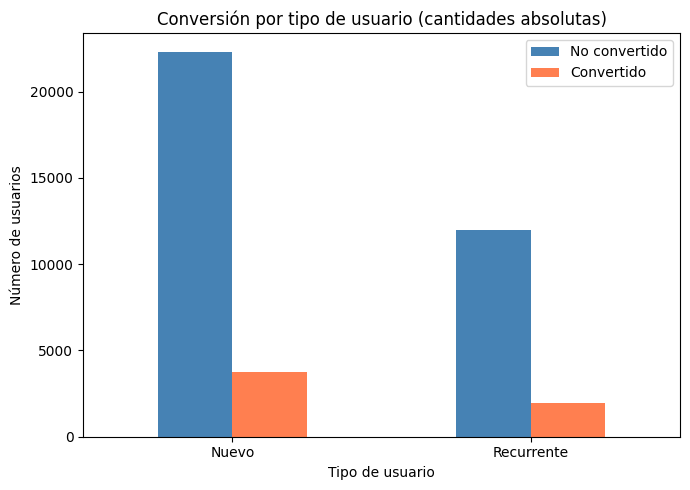

In [ ]:
# Gráfico de barras agrupadas - cantidades absolutas
user_conv = pd.crosstab(df["user_type"], df["converted"])
user_conv.columns = ["No convertido", "Convertido"]
user_conv.plot(kind="bar", figsize=(7, 5), color=["steelblue", "coral"])
plt.title("Conversión por tipo de usuario (cantidades absolutas)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

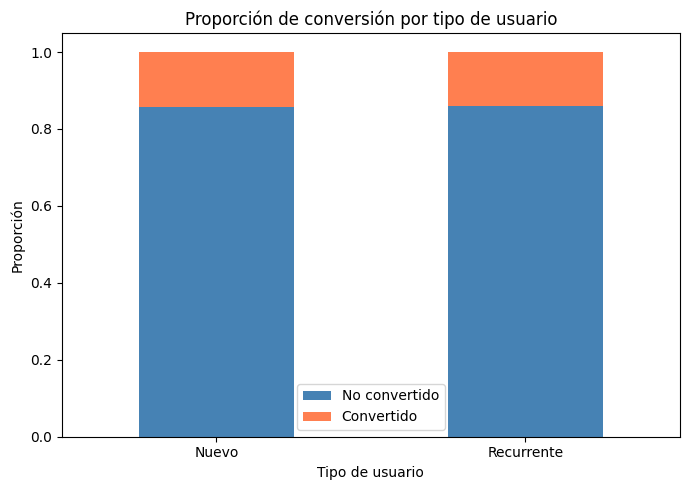

In [ ]:
# Gráfico de barras apiladas - proporciones
user_prop = user_conv.div(user_conv.sum(axis=1), axis=0)
user_prop.plot(kind="bar", stacked=True, figsize=(7, 5), color=["steelblue", "coral"])
plt.title("Proporción de conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

✍️ **Comentario**:

**Gráfico 1** (cantidades absolutas):

Los usuarios nuevos son aproximadamente el doble que los recurrentes en el dataset (~26,033 vs ~13,967). En volumen absoluto, los nuevos generan más conversiones simplemente por ser más numerosos.

**Gráfico 2** (proporciones):

Las barras apiladas son visualmente casi idénticas: usuarios nuevos convierten al 14.36% y recurrentes al 14.09%. La diferencia es tan pequeña que no se aprecia a simple vista, lo que es completamente consistente con el resultado de la prueba chi-cuadrado (p = 0.4736), que confirmó que el tipo de usuario no se asocia con la conversión.

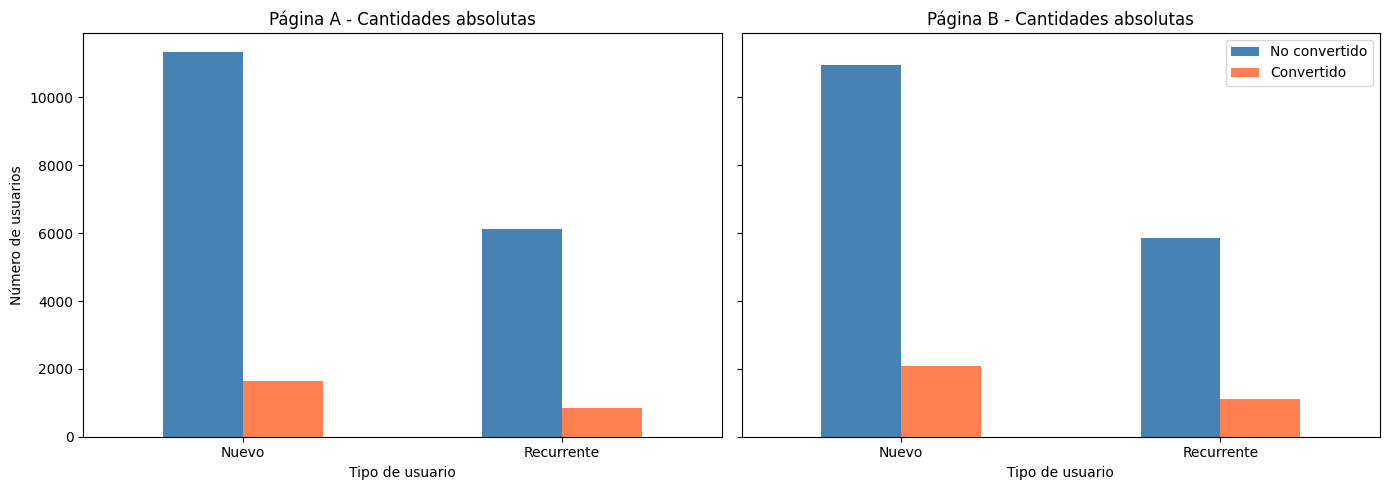

In [ ]:
# Gráfico de barras agrupadas por página - cantidades absolutas
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pagina in zip(axes, ["A", "B"]):
    subset = df[df["landing"] == pagina]
    user_conv = pd.crosstab(subset["user_type"], subset["converted"])
    user_conv.columns = ["No convertido", "Convertido"]
    user_conv.plot(kind="bar", ax=ax, color=["steelblue", "coral"], legend=(ax == axes[1]))
    ax.set_title(f"Página {pagina} - Cantidades absolutas")
    ax.set_xlabel("Tipo de usuario")
    ax.set_ylabel("Número de usuarios")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

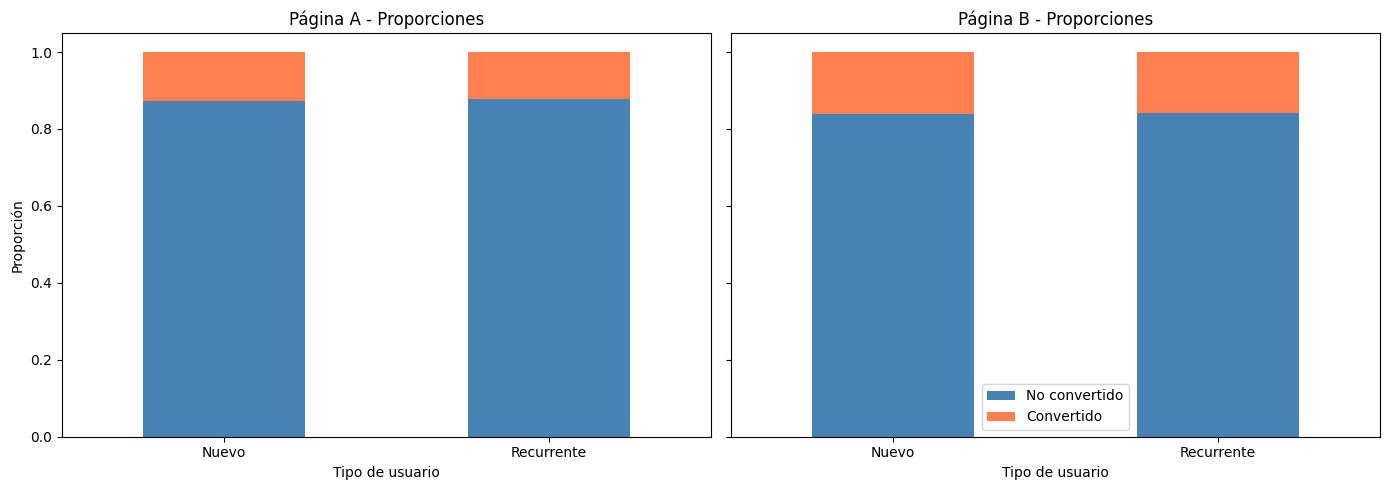

In [ ]:
# Gráfico de barras apiladas por página - proporciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pagina in zip(axes, ["A", "B"]):
    subset = df[df["landing"] == pagina]
    user_conv = pd.crosstab(subset["user_type"], subset["converted"])
    user_conv.columns = ["No convertido", "Convertido"]
    user_prop = user_conv.div(user_conv.sum(axis=1), axis=0)
    user_prop.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "coral"], legend=(ax == axes[1]))
    ax.set_title(f"Página {pagina} - Proporciones")
    ax.set_xlabel("Tipo de usuario")
    ax.set_ylabel("Proporción")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print(df.groupby(["landing", "user_type"])["converted"].mean().round(4) * 100)

landing  user_type 
A        Nuevo         12.73
         Recurrente    12.27
B        Nuevo         15.98
         Recurrente    15.91
Name: converted, dtype: float64


✍️ **Comentario**:

**Gráfico 1 (cantidades absolutas):**
La distribución de usuarios nuevos vs recurrentes es similar entre ambas páginas, con nuevos siendo aproximadamente el doble que recurrentes en ambos casos.

**Gráfico 2 (proporciones):**
En la página A, nuevos convierten al 12.73% y recurrentes al 12.27%, una diferencia de apenas 0.46 puntos. En la página B, nuevos convierten al 15.98% y recurrentes al 15.91%, diferencia de solo 0.07 puntos.

El hallazgo clave es el mismo que con los canales: la página B supera a la página A tanto en usuarios nuevos como recurrentes con una ventaja de aproximadamente 3 puntos porcentuales en ambos segmentos. El tipo de usuario no determina quién convierte más, pero la página B mejora la conversión de forma uniforme en ambos perfiles.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- **La página B** generó un gasto promedio de $68.75 por usuario convertido, frente a
$61.09 de la página A.
- La diferencia de $7.66 por cliente es estadísticamente significativa (p < 0.05, prueba t).
- **Interpretación:** **La página B** no solo convierte más usuarios, sino que también extrae mayor valor económico de cada conversión.

<br>

**Tasa de conversión:**
- **La página B** convirtió al 15.96% de sus usuarios, mientras que la página A lo hizo al 12.57%.
- Esta diferencia de 3.39 puntos porcentuales es estadísticamente significativa (p < 0.05, prueba z).
- **Interpretación:** La página B convirtió al 15.96% de sus usuarios, mientras que la página A lo hizo al 12.57%.
Esta diferencia de 3.39 puntos porcentuales es estadísticamente significativa (p < 0.05, prueba z).

---

#### 📊 **Segmentación por fuente de tráfico**
- **La página B** supera a la página A en todos los canales: Ads (16.49% vs 12.99%), Email (16.50% vs 13.51%), Organic (15.46% vs 12.11%) y Referral (15.74% vs 11.91%). La prueba chi-cuadrado confirmó asociación significativa entre canal y conversión (p = 0.0341).
- **Interpretación:** **Email** y **Ads** son los canales más eficientes en ambas páginas. Priorizar inversión en estos canales combinado con la página B maximizaría el retorno.

 ---

#### 📊 **Segmentación por tipo de usuario**
- Las tasas de conversión entre usuarios nuevos y recurrentes son prácticamente idénticas en ambas páginas (A: 12.73% vs 12.27%; B: 15.98% vs 15.91%). La prueba chi-cuadrado no encontró asociación significativa (p = 0.4736).
- **Interpretación:** El tipo de *usuario* no influye en la probabilidad de conversión, por lo que no es necesario segmentar la estrategia por este criterio. La mejora de la página B beneficia por igual a ambos perfiles.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**

**1. Implementar la página B de forma definitiva.**
La evidencia estadística es contundente: la página B supera a la A tanto en tasa de conversión (+3.39 pp) como en gasto promedio por cliente (+$7.66). No hay segmento, canal ni tipo de usuario en el que la página A sea superior.

**2. Priorizar inversión en Email y Ads.**
Son los canales con mayor tasa de conversión en ambas páginas. Redirigir presupuesto desde Organic hacia estos dos canales optimizaría el retorno de la inversión en marketing, ya que Organic atrae alto volumen pero con menor efectividad relativa.

**3. No segmentar por tipo de usuario.**
Dado que usuarios nuevos y recurrentes convierten a tasas estadísticamente iguales, no se justifica crear experiencias diferenciadas por este criterio. Los recursos destinados a personalización por tipo de usuario podrían redirigirse hacia otras optimizaciones.

**4. Investigar qué elementos de la página B generan mayor gasto.**
La página B no solo convierte más, sino que los clientes gastan más. Vale la pena identificar si hay elementos de diseño, llamadas a la acción, o estructura de oferta que incentivan tickets más altos, para reforzarlos en futuras iteraciones.

**5. Monitorear resultados post-implementación.**
Validar que las métricas observadas en el experimento se mantienen en producción con tráfico real y sin control experimental, especialmente la tasa de conversión y el gasto promedio.